# 🧹 Notebook 2 — Preprocessing Pipeline (Phase 1)

شرح تفاصيل مرحلة تجهيز البيانات خطوة بخطوة:
1. **`clean_text`** — تنظيف HTML والـ artifacts
2. **تصنيف نوع السؤال** — `classify_question_type`
3. **تصنيف المجال** — `classify_domain`
4. **تصنيف الصعوبة** — `classify_difficulty`
5. **Sentence-aware chunking** — `chunk_text`
6. **بناء المستندات** — `build_documents`
---

In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))

import pandas as pd
import matplotlib.pyplot as plt
import json

from app.config import get_settings
from app.rag.preprocessing import (
    clean_text, split_sentences, chunk_text,
    classify_question_type, classify_domain, classify_difficulty,
    answer_length_bucket, build_documents, dataset_statistics, Document
)

settings = get_settings()
CSV_PATH = str(settings.resolve(settings.dataset_path))
df = pd.read_csv(CSV_PATH)
print(f'Loaded {len(df):,} rows from {CSV_PATH}')

Loaded 86,212 rows from E:\DIGISTED_TASK\dataset\Natural-Questions-Filtered.csv


---
## Step 1: `clean_text` — تنظيف النص خطوة بخطوة

In [2]:
# جرّب كل artifact على حدة
test_cases = [
    ('<P> Tracy McConnell , better known as `` The Mother ''. </P>',
     'وسوم HTML + backtick quotes'),
    ("a newsletter sent to an advertising firm 's customers",
     'مسافة قبل apostrophe'),
    ("Tom Brady does n't hold the record",
     "مسافة في n't"),
    ('hello   world  \n\n  test',
     'مسافات وسطور متعددة'),
    ('price : 5 dollars ( tax included ) .',
     'مسافات زائدة قبل علامات ترقيم'),
]

print(f'{"Problem":<45} {"RAW":<50} {"CLEAN"}')
print('─' * 120)
for raw, problem in test_cases:
    cleaned = clean_text(raw)
    print(f'{problem:<45} {raw[:48]:<50} {cleaned}')

Problem                                       RAW                                                CLEAN
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
وسوم HTML + backtick quotes                   <P> Tracy McConnell , better known as `` The Mot   Tracy McConnell, better known as " The Mother.
مسافة قبل apostrophe                          a newsletter sent to an advertising firm 's cust   a newsletter sent to an advertising firm's customers
مسافة في n't                                  Tom Brady does n't hold the record                 Tom Brady doesn't hold the record
مسافات وسطور متعددة                           hello   world  

  test                            hello world test
مسافات زائدة قبل علامات ترقيم                 price : 5 dollars ( tax included ) .               price: 5 dollars (tax included).


In [3]:
# مقارنة شاملة على صف حقيقي من الـ dataset
idx = 1
raw_q  = df['question'].iloc[idx]
raw_la = df['long_answers'].iloc[idx]
raw_sa = df['short_answers'].iloc[idx]

print(f'{'─'*60}')
print(f'سؤال خام   : {raw_q}')
print(f'سؤال نظيف  : {clean_text(raw_q)}')
print()
print(f'إجابة قصيرة خام   : {raw_sa}')
print(f'إجابة قصيرة نظيفة : {clean_text(raw_sa)}')
print()
print(f'إجابة طويلة خام   ({len(str(raw_la))} chars):')
print(str(raw_la)[:300])
print()
print(f'إجابة طويلة نظيفة ({len(clean_text(raw_la))} chars):')
print(clean_text(raw_la)[:300])

────────────────────────────────────────────────────────────
سؤال خام   : how i.met your mother who is the mother
سؤال نظيف  : how i.met your mother who is the mother

إجابة قصيرة خام   : Tracy McConnell
إجابة قصيرة نظيفة : Tracy McConnell

إجابة طويلة خام   (460 chars):
Tracy McConnell, better known as `` The Mother '', is the title character from the CBS television sitcom How I Met Your Mother. The show, narrated by Future Ted, tells the story of how Ted Cosby met The Mother. Tracy McConnell appears in episodes from `` Lucky Penny '' to `` The Time Travelers '' as

إجابة طويلة نظيفة (451 chars):
Tracy McConnell, better known as " The Mother ", is the title character from the CBS television sitcom How I Met Your Mother. The show, narrated by Future Ted, tells the story of how Ted Cosby met The Mother. Tracy McConnell appears in episodes from " Lucky Penny " to " The Time Travelers " as an un


---
## Step 2: تصنيف نوع السؤال

In [4]:
# اختبر classify_question_type على أمثلة واضحة
test_questions = [
    ("what is the speed of light",          "definition"),
    ("who won the world cup in 2018",        "person"),
    ("where is the eiffel tower located",   "location"),
    ("when did world war 2 end",             "temporal"),
    ("how many bones are in the human body","quantity"),
    ("why does the sky look blue",           "reason"),
    ("is python a programming language",     "boolean"),
    ("which country has the largest area",  "selection"),
    ("tom brady nfl wins record",            "factual"),
]

print(f'{"Question":<45} {"Expected":<12} {"Got":<12} {"✓/✗"}')
print('─' * 80)
for q, expected in test_questions:
    got = classify_question_type(q)
    icon = '✓' if got == expected else '✗'
    print(f'{q:<45} {expected:<12} {got:<12} {icon}')

Question                                      Expected     Got          ✓/✗
────────────────────────────────────────────────────────────────────────────────
what is the speed of light                    definition   definition   ✓
who won the world cup in 2018                 person       factual      ✗
where is the eiffel tower located             location     location     ✓
when did world war 2 end                      temporal     temporal     ✓
how many bones are in the human body          quantity     quantity     ✓
why does the sky look blue                    reason       reason       ✓
is python a programming language              boolean      boolean      ✓
which country has the largest area            selection    boolean      ✗
tom brady nfl wins record                     factual      factual      ✓


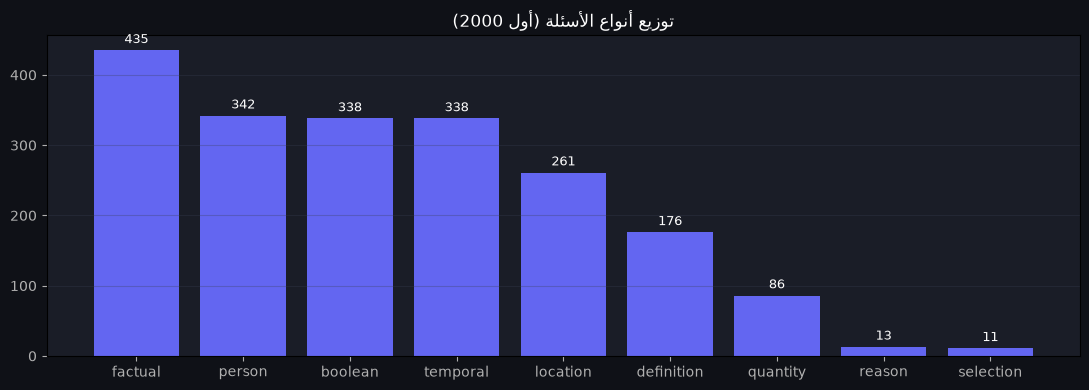

In [5]:
# توزيع الأنواع على أول 2000 سؤال
sample_types = df['question'].head(2000).apply(lambda q: classify_question_type(clean_text(str(q))))
type_counts  = sample_types.value_counts()

fig, ax = plt.subplots(figsize=(11, 4), facecolor='#0f1117')
ax.set_facecolor('#1a1d27')
bars = ax.bar(type_counts.index, type_counts.values, color='#6366f1', edgecolor='none')
ax.bar_label(bars, padding=3, color='white', fontsize=9)
ax.set_title('توزيع أنواع الأسئلة (أول 2000)', color='white', fontsize=12)
ax.tick_params(colors='#b0b0b0')
ax.grid(axis='y', alpha=0.3, color='#3a3f55')
plt.tight_layout(); plt.show()

---
## Step 3: تصنيف المجال والصعوبة

In [6]:
# مثال تفاعلي — اختبر سؤال من عندك
MY_QUESTION = "who won the super bowl in 2020"
MY_ANSWER   = "The Kansas City Chiefs won Super Bowl LIV defeating the San Francisco 49ers."

print('Question type :', classify_question_type(MY_QUESTION))
print('Domain        :', classify_domain(MY_QUESTION, MY_ANSWER))
print('Difficulty    :', classify_difficulty('Kansas City Chiefs', MY_ANSWER))
print('Answer bucket :', answer_length_bucket(MY_ANSWER))

Question type : factual
Domain        : geography
Difficulty    : easy
Answer bucket : short


In [7]:
# تطبيق التصنيف على 500 صف وعرض النتائج
df500 = df.head(500).copy()
df500['q']    = df500['question'].apply(clean_text)
df500['la']   = df500['long_answers'].apply(clean_text)
df500['sa']   = df500['short_answers'].apply(clean_text)
df500['type'] = df500['q'].apply(classify_question_type)
df500['dom']  = df500.apply(lambda r: classify_domain(r['q'], r['la']), axis=1)
df500['diff'] = df500.apply(lambda r: classify_difficulty(r['sa'], r['la']), axis=1)

# عرض crosstab: نوع السؤال × المجال
ct = pd.crosstab(df500['type'], df500['dom'])
print('\nCross-tab: Question Type × Domain (أول 500 صف)')
ct


Cross-tab: Question Type × Domain (أول 500 صف)


dom,entertainment,general,geography,health,history,politics,science,sports,technology
type,,,,,,,,,
boolean,24,5,11,1,10,0,6,6,3
definition,9,4,13,0,4,2,2,4,1
factual,55,12,15,4,8,2,6,5,4
location,14,8,23,1,7,1,3,7,3
person,64,7,4,0,11,3,0,6,1
quantity,5,2,6,0,2,1,3,4,3
reason,0,1,1,0,3,1,0,0,0
selection,0,0,1,0,1,0,0,0,1
temporal,34,3,14,1,12,7,1,13,1


---
## Step 4: Sentence-aware Chunking — شرح مفصّل

In [8]:
# شاهد الـ chunking خطوة بخطوة
SAMPLE_TEXT = clean_text(df['long_answers'].iloc[5])
print(f'النص الأصلي ({len(SAMPLE_TEXT)} chars):')
print(SAMPLE_TEXT)
print()
print('── الجُمل بعد التقسيم ──')
sentences = split_sentences(SAMPLE_TEXT)
for i, s in enumerate(sentences):
    print(f'  [{i}] ({len(s)} chars): {s[:80]}...' if len(s)>80 else f'  [{i}] ({len(s)} chars): {s}')

النص الأصلي (197 chars):
Typically, a driver operating with a learner's permit must be accompanied by an adult licensed driver who is at least 21 years of age or older and in the passenger seat of the vehicle at all times.

── الجُمل بعد التقسيم ──
  [0] (197 chars): Typically, a driver operating with a learner's permit must be accompanied by an ...


In [9]:
# قارن chunk_size مختلفة على نفس النص
configs = [(256,32), (512,64), (768,96)]
print(f'النص: {len(SAMPLE_TEXT)} حرف\n')
for cs, co in configs:
    chunks = chunk_text(SAMPLE_TEXT, cs, co)
    print(f'chunk_size={cs}, overlap={co} → {len(chunks)} chunks')
    for j, c in enumerate(chunks):
        print(f'  Chunk [{j}] ({len(c)} chars): {c[:60]}...')
    print()

النص: 197 حرف

chunk_size=256, overlap=32 → 1 chunks
  Chunk [0] (197 chars): Typically, a driver operating with a learner's permit must b...

chunk_size=512, overlap=64 → 1 chunks
  Chunk [0] (197 chars): Typically, a driver operating with a learner's permit must b...

chunk_size=768, overlap=96 → 1 chunks
  Chunk [0] (197 chars): Typically, a driver operating with a learner's permit must b...



In [12]:
# شوف الـ overlap بين chunks متتالية
cs, co = settings.chunk_size, settings.chunk_overlap
chunks = chunk_text(SAMPLE_TEXT, cs, co)
print("Number of chunks:", len(chunks))
print("Chunk size:", cs)
print("Overlap:", co)

if len(chunks) >= 2:
    print(f'Overlap test (chunk_size={cs}, overlap={co}):')
    end_of_c0   = chunks[0][-co:] if len(chunks[0]) >= co else chunks[0]
    start_of_c1 = chunks[1][:co] if len(chunks[1]) >= co else chunks[1]
    print(f'  نهاية chunk[0]: ...{end_of_c0!r}')
    print(f'  بداية chunk[1]: {start_of_c1!r}...')
    overlap_found = end_of_c0[:20] in chunks[1]
    print(f'  → Overlap موجود: {overlap_found}')

Number of chunks: 1
Chunk size: 384
Overlap: 48


In [13]:
from app.rag.tokenizer_utils import count_tokens

print("Token count:", count_tokens(SAMPLE_TEXT))
print("Chunk size:", settings.chunk_size)

Token count: 49
Chunk size: 384


In [15]:
long_text = " ".join(df["long_answers"].dropna().astype(str).tolist()[:20])

print("Token count:", count_tokens(long_text))
chunks = chunk_text(long_text, settings.chunk_size, settings.chunk_overlap)

print("Number of chunks:", len(chunks))

if len(chunks) >= 2:
    print("Chunk 0 tokens:", count_tokens(chunks[0]))
    print("Chunk 1 tokens:", count_tokens(chunks[1]))
    print("End chunk 0:", chunks[0][-200:])
    print("Start chunk 1:", chunks[1][:200])

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (3083 > 512). Running this sequence through the model will result in indexing errors


Token count: 3083
Number of chunks: 10
Chunk 0 tokens: 345
Chunk 1 tokens: 381
End chunk 0: eepless Night (2011) and Hacker's Game (2015). She plays the role of Mantis in the film Guardians of the Galaxy Vol. (2017) and will appear in the same role in the film Avengers : Infinity War (2018).
Start chunk 1: Sleepless Night (2011) and Hacker's Game (2015). She plays the role of Mantis in the film Guardians of the Galaxy Vol. (2017) and will appear in the same role in the film Avengers : Infinity War (2018


---
## Step 4 (updated): Token-based chunking — multilingual-e5-large

`CHUNK_SIZE` and `CHUNK_OVERLAP` in `.env` are **token counts**, counted with the same tokenizer as the embedding model.


In [16]:
from app.rag.tokenizer_utils import get_embedding_tokenizer, count_tokens, count_embed_passage_tokens

tok = get_embedding_tokenizer(settings.embedding_model)
SAMPLE_TEXT = clean_text(df['long_answers'].iloc[5])
print(f'Answer chars: {len(SAMPLE_TEXT)} | tokens: {count_tokens(SAMPLE_TEXT, tok)}')

for cs, co in [(128, 16), (256, 32), (384, 48)]:
    chunks = chunk_text(SAMPLE_TEXT, cs, co, tokenizer=tok)
    tok_counts = [count_tokens(c, tok) for c in chunks]
    print(f'chunk_size={cs} tok, overlap={co} -> {len(chunks)} chunks, token counts={tok_counts}')


Answer chars: 197 | tokens: 49
chunk_size=128 tok, overlap=16 -> 1 chunks, token counts=[49]
chunk_size=256 tok, overlap=32 -> 1 chunks, token counts=[49]
chunk_size=384 tok, overlap=48 -> 1 chunks, token counts=[49]


---
## Step 5: `build_documents` — الـ Pipeline الكامل

In [17]:
# بنى مستندات من أول 100 صف
docs = build_documents(CSV_PATH, max_rows=100,
                       chunk_size=settings.chunk_size,
                       chunk_overlap=settings.chunk_overlap)

print(f'عدد الـ chunks: {len(docs)}')
print(f'متوسط chunks/سؤال: {len(docs)/100:.2f}')
print()

# افحص مستنداً واحداً بالتفصيل
doc = docs[0]
print('── مستند مثال ──')
print(f'ID           : {doc.id}')
print(f'Question     : {doc.question[:80]}')
print(f'Type         : {doc.question_type}')
print(f'Domain       : {doc.domain}')
print(f'Difficulty   : {doc.difficulty}')
print(f'Answer length: {doc.answer_length}')
print(f'Chunk index  : {doc.chunk_index}')
print(f'Source row   : {doc.source_row}')
print(f'Text (embed) :')
print(doc.text[:400])

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (631 > 512). Running this sequence through the model will result in indexing errors


عدد الـ chunks: 103
متوسط chunks/سؤال: 1.03

── مستند مثال ──
ID           : 07c0228ffcfd5e41e84673143f16df18461587b8
Question     : which is the most common use of opt-in e-mail marketing
Type         : boolean
Domain       : technology
Difficulty   : medium
Answer length: medium
Chunk index  : 0
Source row   : 0
Text (embed) :
Question: which is the most common use of opt-in e-mail marketing
Answer: A common example of permission marketing is a newsletter sent to an advertising firm's customers. Such newsletters inform customers of upcoming events or promotions, or new products. In this type of advertising, a company that wants to send a newsletter to their customers may ask them at the point of purchase if they would l


In [18]:
# payload يُرسل لـ Qdrant
print('── Qdrant Payload ──')
print(json.dumps({k: str(v)[:80] for k,v in docs[0].to_payload().items()}, indent=2, ensure_ascii=False))

── Qdrant Payload ──
{
  "text": "Question: which is the most common use of opt-in e-mail marketing\nAnswer: A comm",
  "question": "which is the most common use of opt-in e-mail marketing",
  "short_answer": "A newsletter sent to an advertising firm's customers",
  "long_answer": "A common example of permission marketing is a newsletter sent to an advertising ",
  "question_type": "boolean",
  "domain": "technology",
  "difficulty": "medium",
  "answer_length": "medium",
  "chunk_index": "0",
  "source_row": "0",
  "token_count": "90"
}


In [19]:
# إحصائيات المجموعة
stats = dataset_statistics(docs)
print(json.dumps(stats, indent=2, ensure_ascii=False))

{
  "total_chunks": 103,
  "unique_questions": 100,
  "avg_chunks_per_question": 1.03,
  "avg_chunk_chars": 610.1,
  "avg_chunk_tokens": 148.8,
  "max_chunk_tokens": 376,
  "by_question_type": {
    "factual": 27,
    "person": 18,
    "temporal": 17,
    "boolean": 15,
    "location": 14,
    "quantity": 6,
    "definition": 4,
    "reason": 1,
    "selection": 1
  },
  "by_domain": {
    "entertainment": 39,
    "geography": 20,
    "history": 13,
    "sports": 12,
    "general": 6,
    "science": 5,
    "technology": 3,
    "health": 3,
    "politics": 2
  },
  "by_difficulty": {
    "medium": 89,
    "easy": 14
  },
  "by_answer_length": {
    "long": 56,
    "medium": 40,
    "short": 7
  }
}


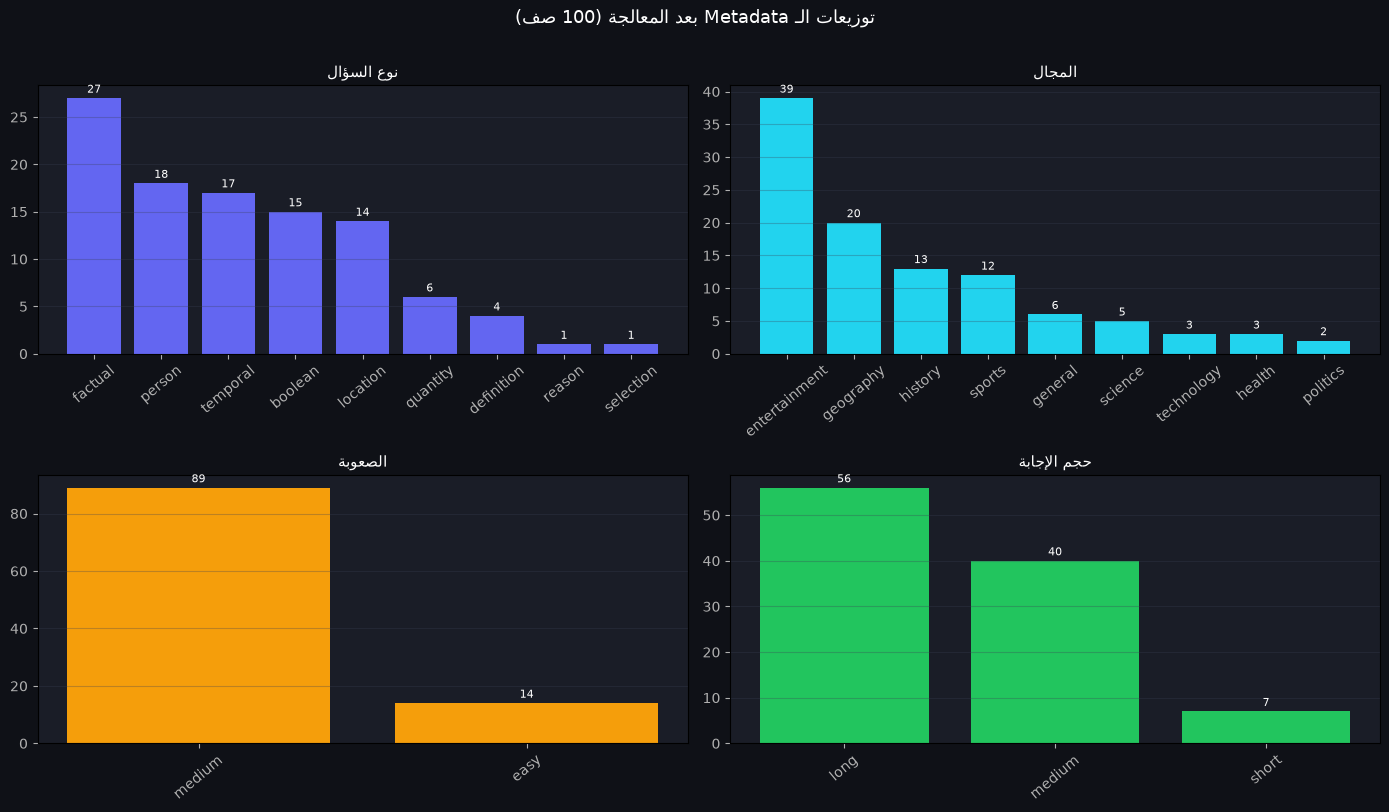

In [20]:
# رسم توزيعات الـ metadata
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 2, figsize=(14, 8), facecolor='#0f1117')
COLORS = ['#6366f1','#22d3ee','#f59e0b','#22c55e']
keys = ['by_question_type','by_domain','by_difficulty','by_answer_length']
titles = ['نوع السؤال','المجال','الصعوبة','حجم الإجابة']

for ax, key, title, color in zip(axes.flat, keys, titles, COLORS):
    ax.set_facecolor('#1a1d27')
    d = stats[key]
    bars = ax.bar(list(d.keys()), list(d.values()), color=color, edgecolor='none')
    ax.bar_label(bars, padding=2, color='white', fontsize=8)
    ax.set_title(title, color='white', fontsize=11)
    ax.tick_params(axis='x', rotation=40, colors='#b0b0b0')
    ax.tick_params(axis='y', colors='#b0b0b0')
    ax.grid(axis='y', alpha=0.3, color='#3a3f55')

plt.suptitle('توزيعات الـ Metadata بعد المعالجة (100 صف)', color='white', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()